<a href="https://colab.research.google.com/github/YogaaAdityaa/uts-sp/blob/main/Soal1_SP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

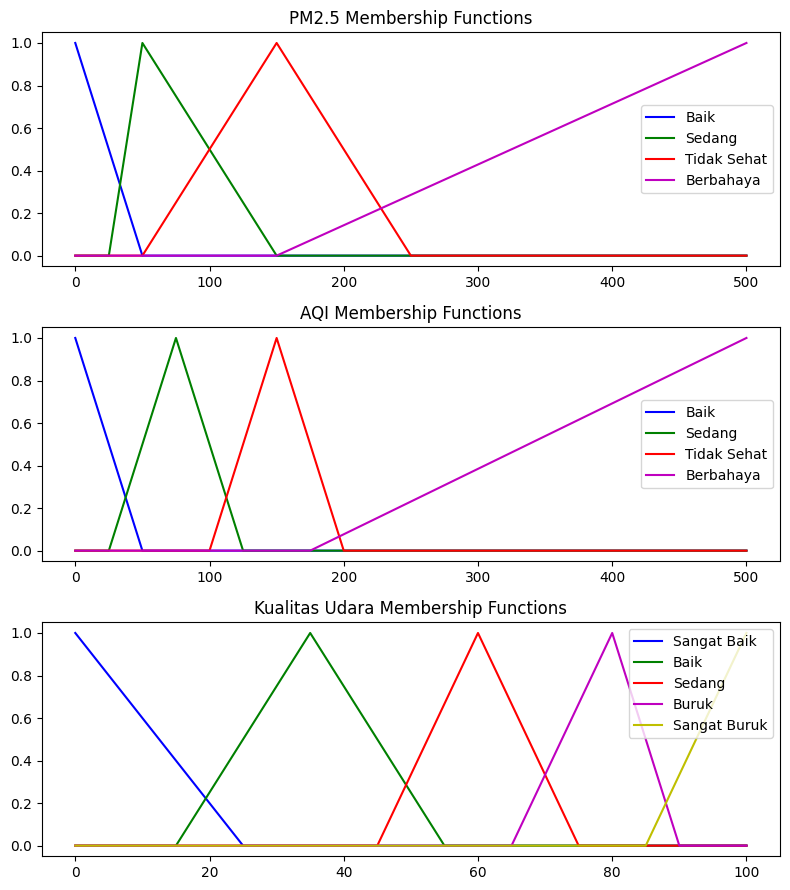

Test Case 1: PM2.5 = 20 µg/m³, AQI = 30
Defuzzified Output (Kualitas Udara): 18.07
Kategori Udara: Sangat Baik
--------------------------------------------------
Test Case 2: PM2.5 = 40 µg/m³, AQI = 80
Defuzzified Output (Kualitas Udara): 50.99
Kategori Udara: Sedang
--------------------------------------------------
Test Case 3: PM2.5 = 100 µg/m³, AQI = 120
Defuzzified Output (Kualitas Udara): 73.51
Kategori Udara: Buruk
--------------------------------------------------
Test Case 4: PM2.5 = 200 µg/m³, AQI = 180
Defuzzified Output (Kualitas Udara): 93.02
Kategori Udara: Sangat Buruk
--------------------------------------------------
Test Case 5: PM2.5 = 300 µg/m³, AQI = 400
Defuzzified Output (Kualitas Udara): 94.64
Kategori Udara: Sangat Buruk
--------------------------------------------------


In [6]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Define parameter
pm25 = ctrl.Antecedent(np.arange(0, 501, 1), 'PM2.5')
aqi = ctrl.Antecedent(np.arange(0, 501, 1), 'AQI')
kualitas = ctrl.Consequent(np.arange(0, 101, 1), 'Kualitas Udara')

# Define membership functions untuk inputs
pm25['Baik'] = fuzz.trimf(pm25.universe, [0, 0, 50])
pm25['Sedang'] = fuzz.trimf(pm25.universe, [25, 50, 150])
pm25['Tidak Sehat'] = fuzz.trimf(pm25.universe, [50, 150, 250])
pm25['Berbahaya'] = fuzz.trimf(pm25.universe, [150, 500, 500])

aqi['Baik'] = fuzz.trimf(aqi.universe, [0, 0, 50])
aqi['Sedang'] = fuzz.trimf(aqi.universe, [25, 75, 125])
aqi['Tidak Sehat'] = fuzz.trimf(aqi.universe, [100, 150, 200])
aqi['Berbahaya'] = fuzz.trimf(aqi.universe, [175, 500, 500])

# Define membership functions untuk output
kualitas['Sangat Baik'] = fuzz.trimf(kualitas.universe, [0, 0, 25])
kualitas['Baik'] = fuzz.trimf(kualitas.universe, [15, 35, 55])
kualitas['Sedang'] = fuzz.trimf(kualitas.universe, [45, 60, 75])
kualitas['Buruk'] = fuzz.trimf(kualitas.universe, [65, 80, 90])
kualitas['Sangat Buruk'] = fuzz.trimf(kualitas.universe, [85, 100, 100])

# Define fuzzy rules
rule1 = ctrl.Rule(pm25['Baik'] & aqi['Baik'], kualitas['Sangat Baik'])
rule2 = ctrl.Rule(pm25['Baik'] & aqi['Sedang'], kualitas['Baik'])
rule3 = ctrl.Rule(pm25['Baik'] & aqi['Tidak Sehat'], kualitas['Sedang'])
rule4 = ctrl.Rule(pm25['Baik'] & aqi['Berbahaya'], kualitas['Buruk'])
rule5 = ctrl.Rule(pm25['Sedang'] & aqi['Baik'], kualitas['Baik'])
rule6 = ctrl.Rule(pm25['Sedang'] & aqi['Sedang'], kualitas['Sedang'])
rule7 = ctrl.Rule(pm25['Sedang'] & aqi['Tidak Sehat'], kualitas['Buruk'])
rule8 = ctrl.Rule(pm25['Sedang'] & aqi['Berbahaya'], kualitas['Sangat Buruk'])
rule9 = ctrl.Rule(pm25['Tidak Sehat'] & aqi['Baik'], kualitas['Sedang'])
rule10 = ctrl.Rule(pm25['Berbahaya'] | aqi['Berbahaya'], kualitas['Sangat Buruk'])

# Control system
kualitas_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10])
kualitas_sim = ctrl.ControlSystemSimulation(kualitas_ctrl)

# Visualisasi membership functions
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9))

ax0.plot(pm25.universe, pm25['Baik'].mf, 'b', linewidth=1.5, label='Baik')
ax0.plot(pm25.universe, pm25['Sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax0.plot(pm25.universe, pm25['Tidak Sehat'].mf, 'r', linewidth=1.5, label='Tidak Sehat')
ax0.plot(pm25.universe, pm25['Berbahaya'].mf, 'm', linewidth=1.5, label='Berbahaya')
ax0.set_title('PM2.5 Membership Functions')
ax0.legend()

ax1.plot(aqi.universe, aqi['Baik'].mf, 'b', linewidth=1.5, label='Baik')
ax1.plot(aqi.universe, aqi['Sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax1.plot(aqi.universe, aqi['Tidak Sehat'].mf, 'r', linewidth=1.5, label='Tidak Sehat')
ax1.plot(aqi.universe, aqi['Berbahaya'].mf, 'm', linewidth=1.5, label='Berbahaya')
ax1.set_title('AQI Membership Functions')
ax1.legend()

ax2.plot(kualitas.universe, kualitas['Sangat Baik'].mf, 'b', linewidth=1.5, label='Sangat Baik')
ax2.plot(kualitas.universe, kualitas['Baik'].mf, 'g', linewidth=1.5, label='Baik')
ax2.plot(kualitas.universe, kualitas['Sedang'].mf, 'r', linewidth=1.5, label='Sedang')
ax2.plot(kualitas.universe, kualitas['Buruk'].mf, 'm', linewidth=1.5, label='Buruk')
ax2.plot(kualitas.universe, kualitas['Sangat Buruk'].mf, 'y', linewidth=1.5, label='Sangat Buruk')
ax2.set_title('Kualitas Udara Membership Functions')
ax2.legend()

plt.tight_layout()
plt.show()

# Uji coba dengan 5 kasus serta menampilkan display defuzzified output + kategori
test_cases = [
    {'PM2.5': 20, 'AQI': 30},  # Sangat Baik
    {'PM2.5': 40, 'AQI': 80},  # Baik
    {'PM2.5': 100, 'AQI': 120},  # Sedang
    {'PM2.5': 200, 'AQI': 180},  # Buruk
    {'PM2.5': 300, 'AQI': 400}   # Sangat Buruk
]

# Fungsi untuk menentukan kategori berdasarkan nilai output crisp
def get_kategori(output_value):
    # Hitung derajat member untuk setiap kategori
    sangat_baik = fuzz.interp_membership(kualitas.universe, kualitas['Sangat Baik'].mf, output_value)
    baik = fuzz.interp_membership(kualitas.universe, kualitas['Baik'].mf, output_value)
    sedang = fuzz.interp_membership(kualitas.universe, kualitas['Sedang'].mf, output_value)
    buruk = fuzz.interp_membership(kualitas.universe, kualitas['Buruk'].mf, output_value)
    sangat_buruk = fuzz.interp_membership(kualitas.universe, kualitas['Sangat Buruk'].mf, output_value)

    # Memilih kategori dengan derajat member tertinggi
    memberships = {
        'Sangat Baik': sangat_baik,
        'Baik': baik,
        'Sedang': sedang,
        'Buruk': buruk,
        'Sangat Buruk': sangat_buruk
    }
    kategori = max(memberships, key=memberships.get)
    return kategori

for i, case in enumerate(test_cases, 1):
    kualitas_sim.input['PM2.5'] = case['PM2.5']
    kualitas_sim.input['AQI'] = case['AQI']
    kualitas_sim.compute()
    output_value = kualitas_sim.output['Kualitas Udara']
    kategori = get_kategori(output_value)
    print(f"Test Case {i}: PM2.5 = {case['PM2.5']} µg/m³, AQI = {case['AQI']}")
    print(f"Defuzzified Output (Kualitas Udara): {output_value:.2f}")
    print(f"Kategori Udara: {kategori}")
    print("-" * 50)
